In [39]:
from google.colab import files
files.upload()

{}

In [40]:
import os

# Create Kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Move file to proper location
!mv kaggle.json /root/.kaggle/

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [41]:
!kaggle datasets download -d jehanbhathena/weather-dataset

Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/weather-dataset
License(s): CC0-1.0
weather-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [42]:
!unzip weather-dataset.zip

Archive:  weather-dataset.zip
replace dataset/dew/2208.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace dataset/dew/2209.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace dataset/dew/2210.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory, plot_model
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [44]:
DATASET_PATH ="dataset"
IMG_SIZE = (128, 128)
BATCH_SIZE =32
EPOCHS = 20

In [45]:
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.
Found 6862 files belonging to 11 classes.
Using 1372 files for validation.


In [46]:
#Further split validation -> Validation + test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

In [47]:
class_names = train_ds.class_names
print(class_names)

['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


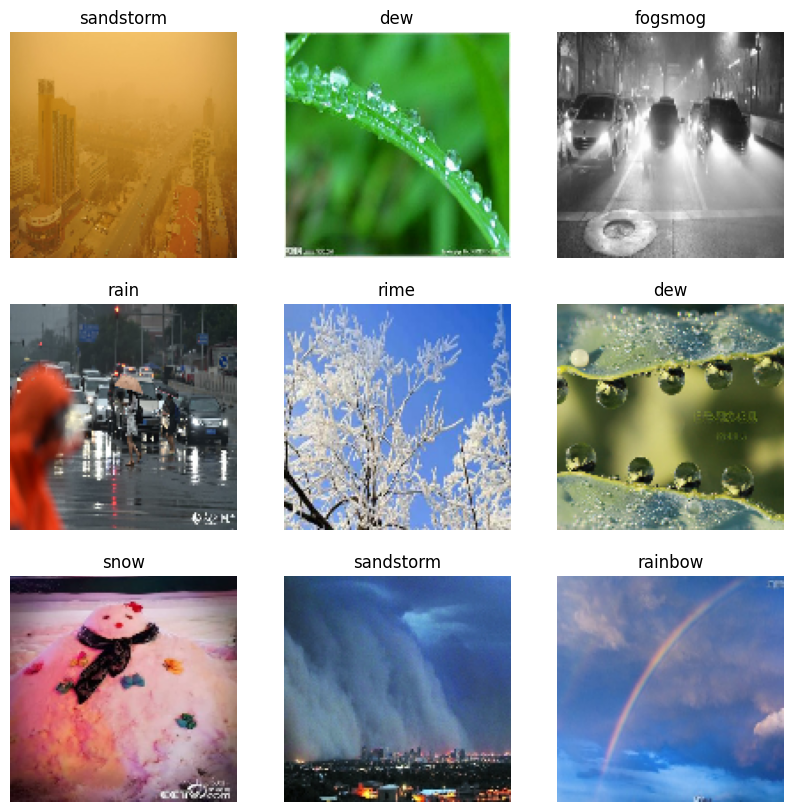

In [48]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3, 3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [49]:
#Class Distribution
class_counts = {}
for class_name in os.listdir(DATASET_PATH):
  class_counts[class_name] = len(os.listdir(os.path.join(DATASET_PATH, class_name)))
print(class_counts)

{'rainbow': 232, 'sandstorm': 692, 'frost': 475, 'dew': 698, 'fogsmog': 851, 'glaze': 639, 'rain': 526, 'snow': 621, 'lightning': 377, 'rime': 1160, 'hail': 591}


/tmp/ipykernel_1769/2591230093.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=class_df, palette='viridis')


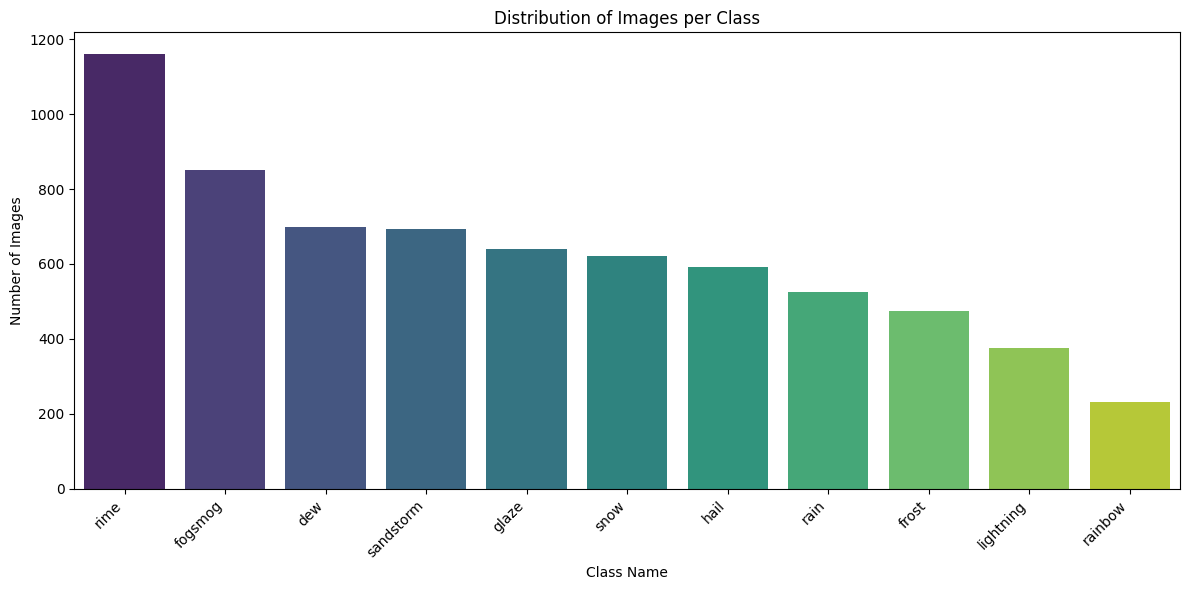

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert class_counts dictionary to a pandas DataFrame for plotting
class_df = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])

# Sort the DataFrame by count for better visualization
class_df = class_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', data=class_df, palette='viridis')
plt.title('Distribution of Images per Class')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
plt.tight_layout()
plt.show()

In [51]:
#Normalization
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [52]:
#Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [53]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,059 (12.61 MB)

 Trainable params: 3,306,059 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

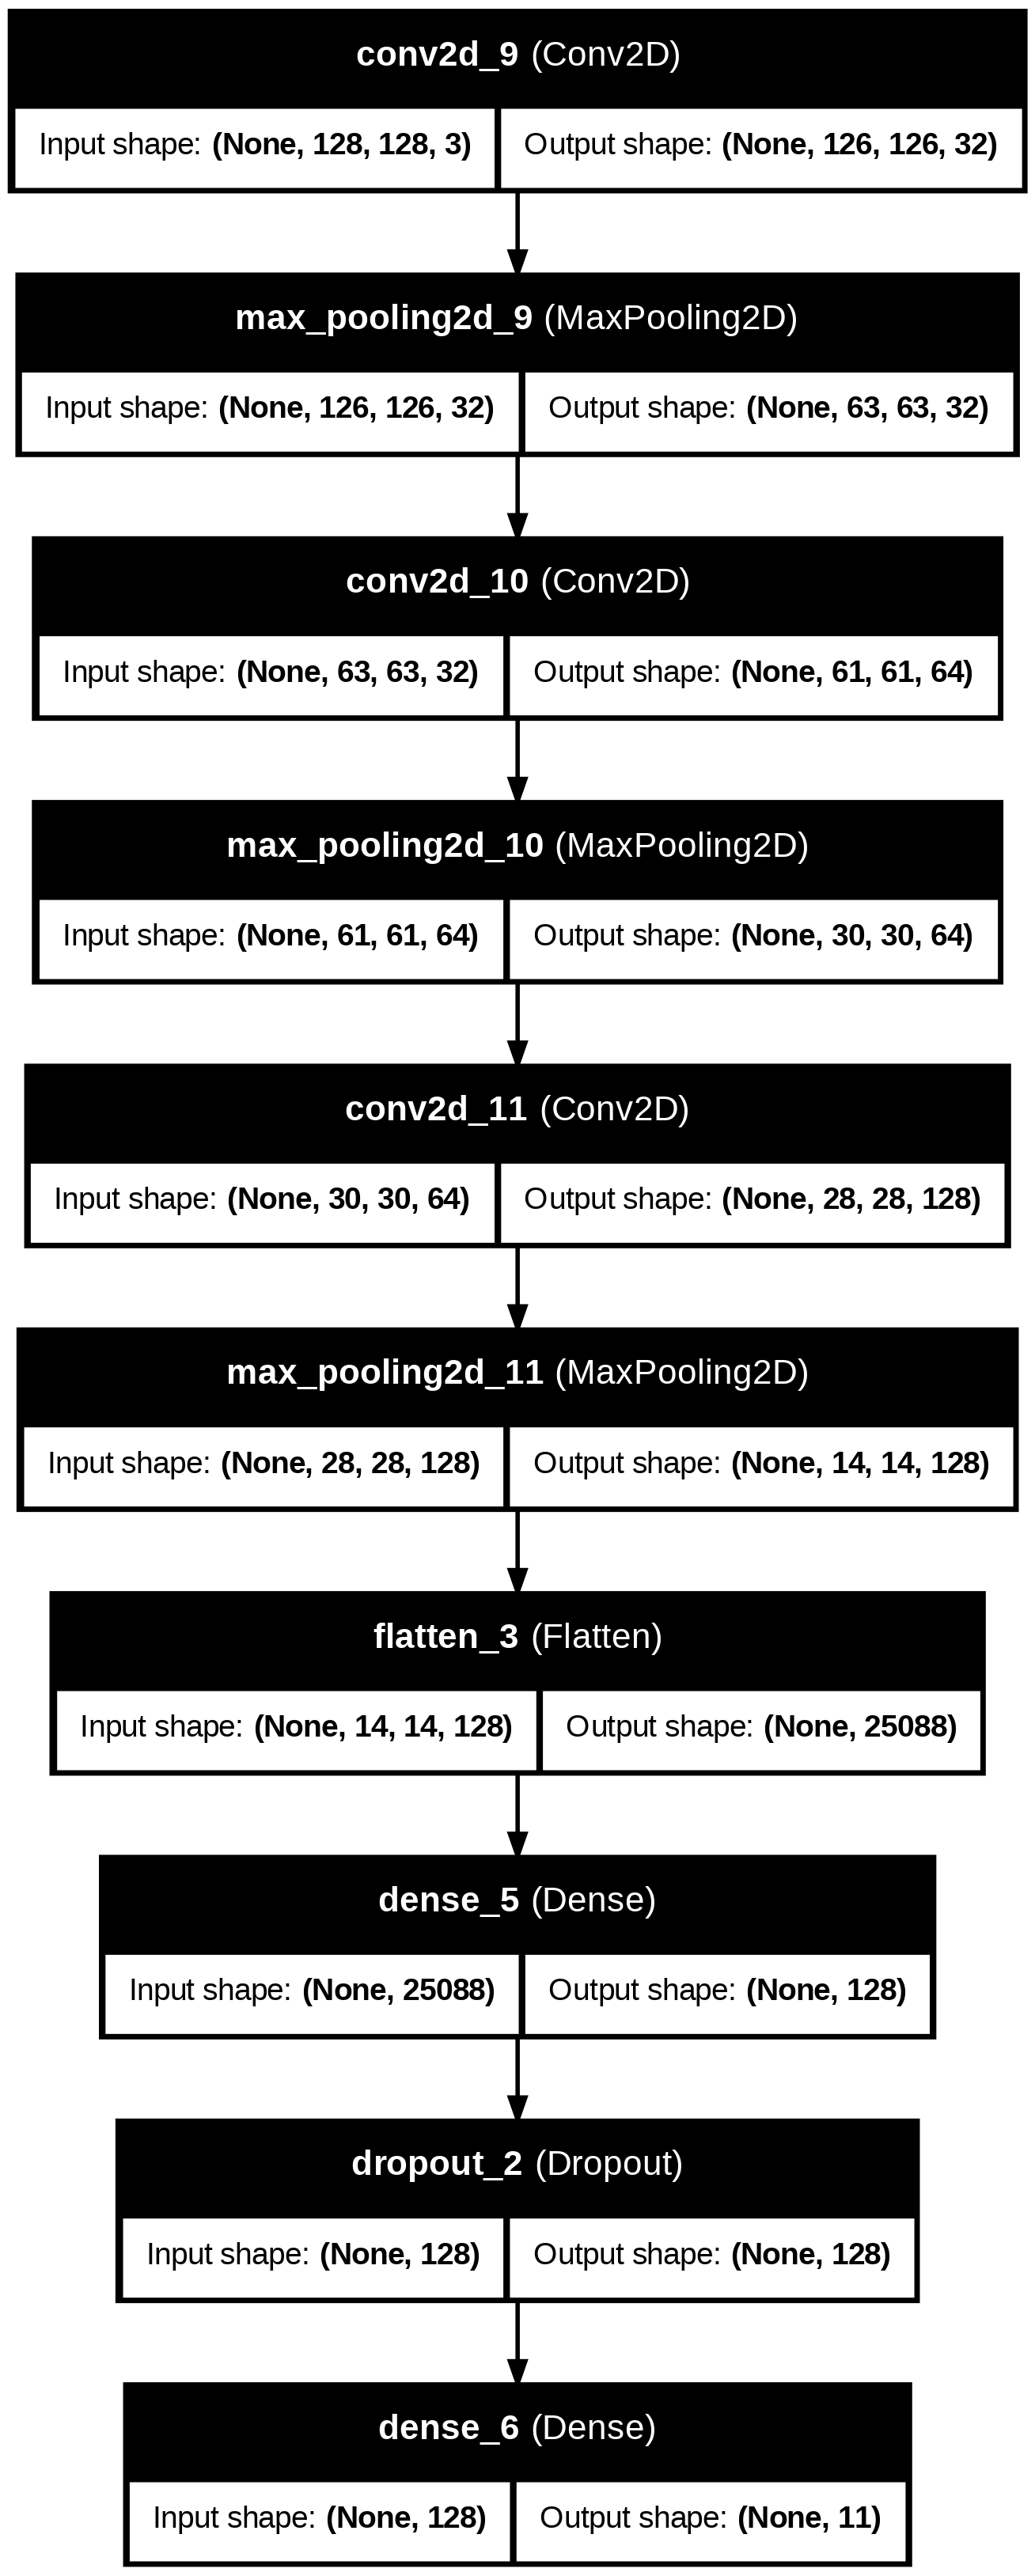

In [54]:
plot_model(model, to_file='model_arch.png', show_shapes=True, show_layer_names=True)

In [55]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [56]:
history=model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.4306 - loss: 1.6651 - val_accuracy: 0.6300 - val_loss: 1.1761
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 32s 31ms/step - accuracy: 0.5770 - loss: 1.2689 - val_accuracy: 0.6286 - val_loss: 1.1203
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.6166 - loss: 1.1349 - val_accuracy: 0.6814 - val_loss: 0.9444
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.6581 - loss: 1.0182 - val_accuracy: 0.7143 - val_loss: 0.9197
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.6867 - loss: 0.9403 - val_accuracy: 0.7200 - val_loss: 0.8724
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.7078 - loss: 0.8649 - val_accuracy: 0.7143 - val_loss: 0.9181
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.7477 - loss: 0.7696 - val_accuracy: 0.7000 - val_loss: 0.9061
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.7652 - loss: 0.6908 - 

In [57]:
loss, acc=model.evaluate(test_ds)
print("Test accuracy: ",acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7426 - loss: 1.2308
Test accuracy:  0.742559552192688


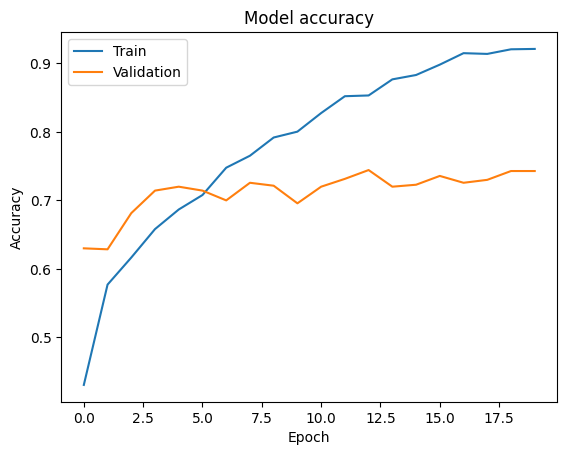

In [58]:
#PLot model accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()